## $\gamma\neq 0$
### Vertical convection (RBC with $\gamma=90^o$)[Zheng et al. [2024](https://doi.org/10.1017/jfm.2024.842)]

\begin{align}
\nabla\cdot \boldsymbol{U} &= 0,\\
\partial_t \boldsymbol{U}+\boldsymbol{U}\cdot\nabla\boldsymbol{U} &= -\nabla P + \sqrt{\frac{Pr}{Ra}}\nabla^2\boldsymbol{U} + T\hat{\mathbf{e}}_y,\\
\partial_t T +\boldsymbol{U}\cdot\nabla T &= \frac{1}{\sqrt{PrRa}}\nabla^2 T.
\end{align}

Macro:
```cpp
// Example 6: RBC [Zheng JFM 2024]
#define P1 sqrt(Pr/Ra) 
#define P2 1.0
#define P3 1.0
#define P5 1.0/sqrt(Pr*Ra)
```

Computational setup:
- Domain: $[L_x,L_y,L_z]=[10,1,1]$ with grid $[96,31,32]$
- $\gamma=90^o$
- $Ra=[5500,14000]$

Symmetries of systems:
- $y$-reflection: $\pi_y[u,v,w,T](x,y,z) \equiv [u,-v,w,T](x,-y,z)$
- Combinated $x$ and $z$ reflections: $\pi_{xz}[u,v,w,T](x,y,z) \equiv [-u,v,-w,-T](-x,y,-z)$
- Translation in $x$ and $z$: $\tau(\Delta y, \Delta z)[u,v,w,T](x,y,z) \equiv [u,v,w,T](x,y+\Delta y,z+\Delta z)$

```text
% 3
  1  1 -1  1   0	0
 -1 -1  1 -1   0	0
  1  1  1  1   0	0.25
```

thus
```text
% 3
  1  1  1 -1   0	0
 -1 -1 -1  1   0	0
  1  1  1  1   0.25	0
```

Commands:
- Create initial conditions: `mpiexec -n 16 ./build/modules/ddc/tools/ddc_initialfield -Nx 96 -Ny 31 -Nz 6 -Lx 10 -ymin -0.5 -ymax 0.5 -Lz 0.004 iniU iniT iniS` for 2D and `mpiexec -n 16 ./build/modules/ddc/tools/ddc_initialfield -Nx 96 -Ny 31 -Nz 32 -Lx 10 -ymin -0.5 -ymax 0.5 -Lz 1 iniU iniT iniS` for 3D
- Simulate: `mpiexec -n 16 ./build/modules/ddc/programs/ddc_simulateflow -o "inclinedILC/" -Pr 0.71 -Ra 6000 -GammaX 90 -Ua 0 -Ub 0 -Ta 0.5 -Tb -0.5 -dT 1e1 -T 200 iniU iniT iniS`
- Find solution: `mpiexec -n 16 ./build/modules/ddc/programs/ddc_findsoln -eqb -od "./solutionsILC/" -Nn 1000 -Pr 0.71 -Ra 6000 -GammaX 90 -Ua 0 -Ub 0 -Ta 0.5 -Tb -0.5 -symms usymms -tsymms tsymms -ssymms ssymms inclinedILC/u8 inclinedILC/t8 inclinedILC/t8` or `mpiexec -n 16 ./build/modules/ddc/programs/ddc_findsoln -eqb -od "./solutionsILC/" -Nn 1000 -Pr 0.71 -Ra 6000 -GammaX 90 -Ua 0 -Ub 0 -Ta 0.5 -Tb -0.5 -symms usymms -tsymms tsymms -ssymms ssymms ub tb sb`
- Continuation: `mpiexec -n 16 ./build/modules/ddc/programs/ddc_continuesoln -eqb -cont Ra -dmu 50 -targ -targMu 14000 -Nn 500 -Ra 5850 -Pr 0.71 -GammaX 90 -Ua 0 -Ub 0 -Ta 0.5 -Tb -0.5 -symms usymms -tsymms tsymms -ssymms ssymms ub tb sb`
- Find eigenvalues: `mpiexec -n 16 ./build/modules/ddc/programs/ddc_findeigenvals -Pr 0.71 -GammaX 90 -Ua 0 -Ub 0 -Ta 0.5 -Tb -0.5 -symms usymms -tsymms tsymms -ssymms ssymms ub tb sb`


<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
C:\Users\jms24002\AppData\Local\Temp\ipykernel_44448\64781302.py:13: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("Data/Validations/Validation_VerticalConvection_Zheng2024/FP1_part1/MuE.asc", sep='\s+')
C:\Users\jms24002\AppData\Local\Temp\ipykernel_44448\64781302.py:18: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("Data/Validations/Validation_VerticalConvection_Zheng2024/FP1_part2/MuE.asc", sep='\s+')
C:\Users\jms24002\AppData\Local\Temp\ipykernel_44448\64781302.py:23: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("Data/Validations/Validation_VerticalConvection_Zheng2024/FP1_part3/MuE.asc", sep='\s+')


(209,)


C:\Users\jms24002\AppData\Local\Temp\ipykernel_44448\64781302.py:36: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv("Data/Validations/Validation_VerticalConvection_Zheng2024/FP1_ref/fp1_ref_data.csv", sep=', ')


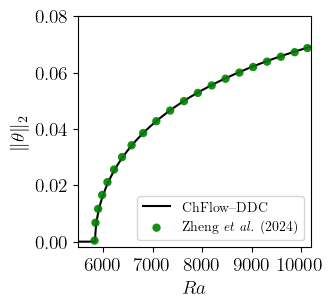

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Set the default font to Times New Roman
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # Use STIX fonts for math symbols
plt.rcParams['text.usetex'] = True # enable LaTeX rendering
# Set the math font to Computer Modern
# plt.rcParams['mathtext.fontset'] = 'cm'
# plt.rcParams['font.family'] = 'serif'

df = pd.read_csv("Data/Validations/Validation_VerticalConvection_Zheng2024/FP1_part1/MuE.asc", sep='\s+')
array = df.values
Ra_p1 = array[:,0]
L2Temp_p1 = array[:,13]

df = pd.read_csv("Data/Validations/Validation_VerticalConvection_Zheng2024/FP1_part2/MuE.asc", sep='\s+')
array = df.values
Ra_p2 = array[:,0]
L2Temp_p2 = array[:,13]

df = pd.read_csv("Data/Validations/Validation_VerticalConvection_Zheng2024/FP1_part3/MuE.asc", sep='\s+')
array = df.values
Ra_p3 = array[:,0]
L2Temp_p3 = array[:,13]

Ra = np.array(np.append(np.append(Ra_p1,Ra_p2),Ra_p3))
L2Temp = np.array(np.append(np.append(L2Temp_p1,L2Temp_p2),L2Temp_p3))
sort_order = np.argsort(Ra)
Ra = Ra[sort_order]
L2Temp = L2Temp[sort_order]

print(np.shape(Ra))

df = pd.read_csv("Data/Validations/Validation_VerticalConvection_Zheng2024/FP1_ref/fp1_ref_data.csv", sep=', ')
array = df.values
Ra_ref = array[:,0]
L2Temp_ref = array[:,1]

plt.figure(figsize=(3, 3))
plt.plot(Ra,L2Temp,color='k',label=r'ChFlow--DDC', zorder=1)
plt.scatter(Ra_ref,L2Temp_ref,color='g',edgecolors='none',alpha=0.9,label=r'Zheng \textit{et al.} (2024)', zorder=2)
plt.xlabel(r'$Ra$', fontsize=14)
plt.ylabel(r'$\|\theta\|_2$', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim([5500, 10200])
plt.ylim([-0.002, 0.08])
plt.legend()
# plt.grid(True)
plt.savefig('Data/Validations/Validation_VerticalConvection_Zheng2024/vertical_convection_Zheng2024.png', dpi=300, bbox_inches='tight')
plt.show()

Commands:
- Create initial conditions: `mpiexec -n 16 ./build/modules/ddc/tools/ddc_initialfield -Nx 96 -Ny 31 -Nz 6 -Lx 10 -ymin -0.5 -ymax 0.5 -Lz 0.004 iniU iniT iniS` for 2D and `mpiexec -n 16 ./build/modules/ddc/tools/ddc_initialfield -Nx 96 -Ny 31 -Nz 32 -Lx 10 -ymin -0.5 -ymax 0.5 -Lz 1 iniU iniT iniS` for 3D
- Simulate: `mpiexec -n 16 ./build/modules/ddc/programs/ddc_simulateflow -o "inclinedDDC/" -Pr 0.71 -Ra 6000 -Le 100 -Ri 1 -Rr 2 -GammaX 90 -Ua 0 -Ub 0 -Ta 0.5 -Tb -0.5 -Sa 0.5 -Sb -0.5 -dt 0.02 -dT 1e1 -T 1000 iniU iniT iniS`
- Find solution: `mpiexec -n 16 ./build/modules/ddc/programs/ddc_findsoln -eqb -Nn 100 -Pr 0.71 -Ra 6000 -GammaX 90 -Ua 0 -Ub 0 -Ta 0.5 -Tb -0.5 -sigma sigma inclinedDDC/u10 inclinedDDC/t10 inclinedDDC/t10`
- Continuation: `mpiexec -n 16 ./build/modules/ddc/programs/ddc_continuesoln -eqb -cont Ra -Pr 0.71 -GammaX 90 -Ua 0 -Ub 0 -Ta 0.5 -Tb -0.5 iniU iniT iniS`


Check results obtained by ILC code:
`mpiexec -n 16 ./build/modules/ilc/programs/ilc_findsoln -eqb -od "./solutionsILC/" -Nn 1000 -Pr 0.71 -Ra 6000 -gx 90 -ilcUw 0 -delT 1 -symms usymms -tsymms tsymms ub tb` and 
`mpiexec -n 16 ./build/modules/ddc/programs/ddc_findsoln -eqb -od "./solutionsILC/" -Nn 1000 -Pr 0.71 -Ra 6000 -GammaX 90 -Ua 0 -Ub 0 -Ta 0.5 -Tb -0.5 -symms usymms -tsymms tsymms -ssymms ssymms ub tb sb`